# ROJECT TITLE -- DATA ANALYSIS  REFRIGERATOR 

## ➡️ Project Objective 

The goal of this project is to extract detailed data of the  Refrigerator  from Flipkart using web scraping 
techniques, clean and organize the data using Python, and analyze it through visualizations.

In [4]:
import requests
from bs4 import BeautifulSoup
import re
import time
import random
import pandas as pd

# 1️ Headers & Session
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
    "DNT": "1"
}

session = requests.Session()
session.headers.update(headers)

# Search Categories
categories = [
    "single+door+refrigerator",
    "double+door+refrigerator",
    "side+by+side+refrigerator",
    "frost+free+refrigerator",
    "mini+refrigerator",
    "smart+refrigerator",
    "inverter+refrigerator"
]

pages_per_category = 7 

# Storage Lists
product_name = []
product_price = []
product_brand = []
product_compressor = []
product_capacity = []

seen_products = set()

#  Scraping Loop
for cat in categories:
    print(f"\nScraping Category: {cat.replace('+', ' ')}")
    for page in range(1, pages_per_category + 1):
        url = f"https://www.amazon.in/s?k={cat}&page={page}"
        try:
            response = session.get(url)
        except:
            print(f"Failed to fetch {url}")
            continue

        print(f"Page {page} Status: {response.status_code}")
        if response.status_code != 200:
            time.sleep(random.uniform(5, 8))
            continue

        soup = BeautifulSoup(response.text)
        products = soup.select("div.s-result-item[data-component-type='s-search-result']")

        print(f"Products found on page: {len(products)}")

        for p in products:
            # Name
            name_tag = p.h2
            name = name_tag.text.strip() if name_tag else None
            if not name:
                continue
            # Optional deduplication
            if name in seen_products:
                continue
            seen_products.add(name)
            product_name.append(name)

            # Price
            price_tag = p.select_one("span.a-price-whole")
            price = price_tag.text.replace(",", "") if price_tag else None
            product_price.append(price)

            # Brand (first word of name)
            brand = name.split()[0]
            product_brand.append(brand)

            # Compressor type (check name)
            if "inverter" in name.lower():
                product_compressor.append("Inverter")
            else:
                product_compressor.append("Non-Inverter")

           # Capacity (look for L or litre in name)
            cap_match = re.search(r'(\d{2,4})\s?L', name, re.IGNORECASE)
            capacity = int(cap_match.group(1)) if cap_match else None
            product_capacity.append(capacity)


        # Random delay to avoid bot detection
        time.sleep(random.uniform(3, 6))

#  Create DataFrame
df = pd.DataFrame({
    "Product_Name": product_name,
    "Brand": product_brand,
    "Price": product_price,
    "Compressor": product_compressor,
    "Capacity": product_capacity
})

print(f"\nTotal rows scraped: {len(df)}")


Scraping Category: single door refrigerator
Page 1 Status: 503
Page 2 Status: 200
Products found on page: 16
Page 3 Status: 200
Products found on page: 22
Page 4 Status: 200
Products found on page: 22
Page 5 Status: 200
Products found on page: 16
Page 6 Status: 200
Products found on page: 22
Page 7 Status: 200
Products found on page: 22

Scraping Category: double door refrigerator
Page 1 Status: 200
Products found on page: 22
Page 2 Status: 200
Products found on page: 22
Page 3 Status: 200
Products found on page: 22
Page 4 Status: 200
Products found on page: 22
Page 5 Status: 200
Products found on page: 22
Page 6 Status: 200
Products found on page: 22
Page 7 Status: 200
Products found on page: 22

Scraping Category: side by side refrigerator
Page 1 Status: 200
Products found on page: 22
Page 2 Status: 200
Products found on page: 22
Page 3 Status: 200
Products found on page: 22
Page 4 Status: 200
Products found on page: 22
Page 5 Status: 200
Products found on page: 22
Page 6 Status: 20

In [5]:
df

,Product_Name,Brand,Price,Compressor,Capacity
0,Whirlpool 184 L 3 Star Direct-Cool Single Door...,Whirlpool,12790,Non-Inverter,184.0
1,Whirlpool 184 L 5 Star Direct-Cool Single Door...,Whirlpool,16490,Inverter,184.0
2,acer 190L 2 Star Direct-Cool Single Door Refri...,acer,11499,Non-Inverter,190.0
3,"Voltas Beko, A Tata Product 183 L 2 Star Direc...",Voltas,12190,Non-Inverter,183.0
4,CANDY 165L 1 Star Direct Cool Single Door Refr...,CANDY,9890,Non-Inverter,165.0
...,...,...,...,...,...
400,Whirlpool 184 L 4 Star Inverter Direct-Cool Si...,Whirlpool,15840,Inverter,184.0
401,"LG 185 L, 5 Star, Smart Inverter, Direct Cool ...",LG,17490,Inverter,185.0
402,"Samsung 183 L, 2 Star, Digital Inverter, Direc...",Samsung,None,Inverter,183.0
403,Whirlpool 184 L 2 Star Direct-Cool Single Door...,Whirlpool,12890,Non-Inverter,184.0


## ➡️ EDA (Exploratory Data Analysis)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_Name  405 non-null    object 
 1   Brand         405 non-null    object 
 2   Price         304 non-null    object 
 3   Compressor    405 non-null    object 
 4   Capacity      339 non-null    float64
dtypes: float64(1), object(4)
memory usage: 15.9+ KB


In [8]:
df.shape

(405, 5)

In [9]:
df.columns

Index(['Product_Name', 'Brand', 'Price', 'Compressor', 'Capacity'], dtype='object')

## ➡️ Data Cleaning And Data Pre-Processing 

In [11]:
df['star_rating'] = df['Product_Name'].str.extract(r'(\d+)\s*(?:Star|star)\b', expand=False)

In [12]:
df['star_rating'] = pd.to_numeric(df['star_rating'], errors='coerce')


In [13]:
df['fridge_type'] = df['Product_Name'].str.extract(
    r'(Single Door|Double Door|Side by Side|French Door)',
    flags=re.IGNORECASE
)


In [14]:
df['fridge_type'] = (
    df['fridge_type']
    .str.strip()
    .str.lower()
)


In [15]:
df['cooling_type'] = df['Product_Name'].str.extract(
    r'(Direct Cool|Frost Free)',
    flags=re.IGNORECASE
)


In [16]:
df['convertible'] = df['Product_Name'].str.contains(
    'Convertible', case=False, na=False
)


In [17]:
df['Smart'] = df['Product_Name'].str.contains('smart', case=False, na=False)

In [18]:
df['Water_Dispenser'] = df['Product_Name'].str.contains('water\s*dispenser', case=False, na=False)

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_28328\3045081151.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df['Water_Dispenser'] = df['Product_Name'].str.contains('water\s*dispenser', case=False, na=False)


## ➡️ Handling Missing Values 

In [20]:
# 1. Convert price column to numeric (invalid values → NaN)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# 2. Fill NaN values with median
df['Price'].fillna(df['Price'].median(), inplace=True)


In [21]:
df

,Product_Name,Brand,Price,Compressor,Capacity,star_rating,fridge_type,cooling_type,convertible,Smart,Water_Dispenser
0,Whirlpool 184 L 3 Star Direct-Cool Single Door...,Whirlpool,12790.0,Non-Inverter,184.0,3.0,single door,NaN,False,False,False
1,Whirlpool 184 L 5 Star Direct-Cool Single Door...,Whirlpool,16490.0,Inverter,184.0,5.0,single door,NaN,False,False,False
2,acer 190L 2 Star Direct-Cool Single Door Refri...,acer,11499.0,Non-Inverter,190.0,2.0,single door,NaN,False,False,False
3,"Voltas Beko, A Tata Product 183 L 2 Star Direc...",Voltas,12190.0,Non-Inverter,183.0,2.0,single door,Direct Cool,False,False,False
4,CANDY 165L 1 Star Direct Cool Single Door Refr...,CANDY,9890.0,Non-Inverter,165.0,1.0,single door,Direct Cool,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
400,Whirlpool 184 L 4 Star Inverter Direct-Cool Si...,Whirlpool,15840.0,Inverter,184.0,4.0,single door,NaN,False,False,False
401,"LG 185 L, 5 Star, Smart Inverter, Direct Cool ...",LG,17490.0,Inverter,185.0,5.0,single door,Direct Cool,False,True,False
402,"Samsung 183 L, 2 Star, Digital Inverter, Direc...",Samsung,18490.0,Inverter,183.0,2.0,single door,NaN,False,False,False
403,Whirlpool 184 L 2 Star Direct-Cool Single Door...,Whirlpool,12890.0,Non-Inverter,184.0,2.0,single door,NaN,False,False,False


In [22]:
df['cooling_type'].value_counts(dropna=False)


cooling_type
NaN            192
Frost Free     136
Direct Cool     71
Frost free       6
Name: count, dtype: int64

In [23]:
import numpy as np

df['cooling_type'] = (
    df['cooling_type']
    .replace('None', np.nan)
    .astype(str)
    .str.lower()
    .str.strip()
)


In [24]:
cooling_map = {
    'frost free': 'Frost Free',
    'direct cool': 'Direct Cool'
}

df['cooling_type'] = df['cooling_type'].map(cooling_map)


In [25]:
def infer_cooling_type(name):
    if pd.isna(name):
        return None
    name = name.lower()
    if 'frost free' in name or 'frost-free' in name:
        return 'Frost Free'
    elif 'direct cool' in name or 'direct-cool' in name:
        return 'Direct Cool'
    return None

df['cooling_type'] = df['cooling_type'].fillna(
    df['Product_Name'].apply(infer_cooling_type)
)


In [26]:
df['cooling_type'] = df['cooling_type'].fillna('Unknown')


In [27]:
df['cooling_type'].value_counts(dropna=False)


cooling_type
Frost Free     170
Direct Cool    133
Unknown        102
Name: count, dtype: int64

In [28]:
df['fridge_type'].value_counts(dropna=False)

fridge_type
single door     145
double door     118
NaN             100
side by side     33
french door       9
Name: count, dtype: int64

In [29]:
df['fridge_type'] = df['fridge_type'].fillna('unknown')

In [30]:
df['fridge_type'].value_counts(dropna=False)

fridge_type
single door     145
double door     118
unknown         100
side by side     33
french door       9
Name: count, dtype: int64

In [31]:
def extract_defrost_type(name):
    if pd.isna(name):
        return None

    name = name.lower()

    if 'auto defrost' in name or 'automatic defrost' in name:
        return 'Auto Defrost'
    elif 'manual defrost' in name:
        return 'Manual Defrost'
    else:
        return None


In [32]:
df['defrost_type'] = df['Product_Name'].apply(extract_defrost_type)


In [33]:
df.loc[
    (df['defrost_type'].isna()) & (df['cooling_type'] == 'Frost Free'),
    'defrost_type'
] = 'Auto Defrost'

df.loc[
    (df['defrost_type'].isna()) & (df['cooling_type'] == 'Direct Cool'),
    'defrost_type'
] = 'Manual Defrost'


In [34]:
df['defrost_type'] = df['defrost_type'].fillna('Unknown')

In [35]:
df.drop(df[df['defrost_type'] == 'Unknown'].index, inplace=True)


In [36]:
df['defrost_type'].value_counts()

defrost_type
Auto Defrost      173
Manual Defrost    130
Name: count, dtype: int64

In [37]:
df['price_range'] = pd.qcut(
    df['Price'],
    q=3,
    labels=['Low', 'Mid', 'Premium']
)


In [38]:
def price_category(price):
    if price < 15000:
        return 'Low'
    elif price <= 30000:
        return 'Mid'
    else:
        return 'Premium'

df['price_range'] = df['Price'].apply(price_category)


In [39]:
df['price_range'].value_counts()

price_range
Mid        177
Premium     82
Low         44
Name: count, dtype: int64

In [40]:
df

,Product_Name,Brand,Price,Compressor,Capacity,star_rating,fridge_type,cooling_type,convertible,Smart,Water_Dispenser,defrost_type,price_range
0,Whirlpool 184 L 3 Star Direct-Cool Single Door...,Whirlpool,12790.0,Non-Inverter,184.0,3.0,single door,Direct Cool,False,False,False,Manual Defrost,Low
1,Whirlpool 184 L 5 Star Direct-Cool Single Door...,Whirlpool,16490.0,Inverter,184.0,5.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid
2,acer 190L 2 Star Direct-Cool Single Door Refri...,acer,11499.0,Non-Inverter,190.0,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low
3,"Voltas Beko, A Tata Product 183 L 2 Star Direc...",Voltas,12190.0,Non-Inverter,183.0,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low
4,CANDY 165L 1 Star Direct Cool Single Door Refr...,CANDY,9890.0,Non-Inverter,165.0,1.0,single door,Direct Cool,False,False,False,Manual Defrost,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,Whirlpool 184 L 4 Star Inverter Direct-Cool Si...,Whirlpool,15840.0,Inverter,184.0,4.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid
401,"LG 185 L, 5 Star, Smart Inverter, Direct Cool ...",LG,17490.0,Inverter,185.0,5.0,single door,Direct Cool,False,True,False,Manual Defrost,Mid
402,"Samsung 183 L, 2 Star, Digital Inverter, Direc...",Samsung,18490.0,Inverter,183.0,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid
403,Whirlpool 184 L 2 Star Direct-Cool Single Door...,Whirlpool,12890.0,Non-Inverter,184.0,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low


In [41]:
df['Capacity'].isna().sum()

np.int64(2)

In [42]:
# Calculate median of the Capacity column
median_capacity = df['Capacity'].median()

# Fill missing values with the median
df['Capacity'].fillna(median_capacity, inplace=True)


In [43]:
df['Capacity'].isna().sum()

np.int64(0)

In [44]:
median_star_rating=df['star_rating'].median()
df['star_rating'].fillna(median_star_rating,inplace=True)

In [45]:
df

,Product_Name,Brand,Price,Compressor,Capacity,star_rating,fridge_type,cooling_type,convertible,Smart,Water_Dispenser,defrost_type,price_range
0,Whirlpool 184 L 3 Star Direct-Cool Single Door...,Whirlpool,12790.0,Non-Inverter,184.0,3.0,single door,Direct Cool,False,False,False,Manual Defrost,Low
1,Whirlpool 184 L 5 Star Direct-Cool Single Door...,Whirlpool,16490.0,Inverter,184.0,5.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid
2,acer 190L 2 Star Direct-Cool Single Door Refri...,acer,11499.0,Non-Inverter,190.0,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low
3,"Voltas Beko, A Tata Product 183 L 2 Star Direc...",Voltas,12190.0,Non-Inverter,183.0,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low
4,CANDY 165L 1 Star Direct Cool Single Door Refr...,CANDY,9890.0,Non-Inverter,165.0,1.0,single door,Direct Cool,False,False,False,Manual Defrost,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,Whirlpool 184 L 4 Star Inverter Direct-Cool Si...,Whirlpool,15840.0,Inverter,184.0,4.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid
401,"LG 185 L, 5 Star, Smart Inverter, Direct Cool ...",LG,17490.0,Inverter,185.0,5.0,single door,Direct Cool,False,True,False,Manual Defrost,Mid
402,"Samsung 183 L, 2 Star, Digital Inverter, Direc...",Samsung,18490.0,Inverter,183.0,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid
403,Whirlpool 184 L 2 Star Direct-Cool Single Door...,Whirlpool,12890.0,Non-Inverter,184.0,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low


In [46]:
df['Capacity'] = df['Capacity'].astype(int)


In [47]:
mapping = {
    'single door': 'Single Door',
    'double door': 'Double Door',
    'side by side': 'Side-by-Side',
    'french door': 'French Door / Multi Door',
    'side by side': 'Side-by-Side',         
    'side_by_side': 'Side-by-Side',
    'french': 'French Door / Multi Door',
    # add more variants you see
}
counts = df['fridge_type'].value_counts()
small = counts[counts < 15].index   # or < 10, < 20 — your call
df['fridge_type_clean'] = df['fridge_type'].replace(mapping)
df['fridge_type_clean'] = df['fridge_type_clean'].replace(small, 'Other / Multi Door')


In [48]:
df['fridge_type_clean'].value_counts()


fridge_type_clean
Single Door                 132
Double Door                 114
unknown                      27
Side-by-Side                 21
French Door / Multi Door      9
Name: count, dtype: int64

In [49]:
df.drop(df[df['fridge_type_clean'] == 'unknown'].index, inplace=True)


In [50]:
df['star_rating'].value_counts()

star_rating
3.0    126
2.0     74
5.0     42
4.0     21
1.0     13
Name: count, dtype: int64

In [51]:
# Define the bins
bins = [0, 2, 4, 5]  # 0-2: Low, 2-4: Medium, 4-5: High
labels = ['Low', 'Medium', 'High']

# Create a new column 'Rating_Category' based on star_rating
df['Rating_Category'] = pd.cut(df['star_rating'], bins=bins, labels=labels, include_lowest=True)


In [52]:
df

,Product_Name,Brand,Price,Compressor,Capacity,star_rating,fridge_type,cooling_type,convertible,Smart,Water_Dispenser,defrost_type,price_range,fridge_type_clean,Rating_Category
0,Whirlpool 184 L 3 Star Direct-Cool Single Door...,Whirlpool,12790.0,Non-Inverter,184,3.0,single door,Direct Cool,False,False,False,Manual Defrost,Low,Single Door,Medium
1,Whirlpool 184 L 5 Star Direct-Cool Single Door...,Whirlpool,16490.0,Inverter,184,5.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid,Single Door,High
2,acer 190L 2 Star Direct-Cool Single Door Refri...,acer,11499.0,Non-Inverter,190,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low,Single Door,Low
3,"Voltas Beko, A Tata Product 183 L 2 Star Direc...",Voltas,12190.0,Non-Inverter,183,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low,Single Door,Low
4,CANDY 165L 1 Star Direct Cool Single Door Refr...,CANDY,9890.0,Non-Inverter,165,1.0,single door,Direct Cool,False,False,False,Manual Defrost,Low,Single Door,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,Whirlpool 184 L 4 Star Inverter Direct-Cool Si...,Whirlpool,15840.0,Inverter,184,4.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid,Single Door,Medium
401,"LG 185 L, 5 Star, Smart Inverter, Direct Cool ...",LG,17490.0,Inverter,185,5.0,single door,Direct Cool,False,True,False,Manual Defrost,Mid,Single Door,High
402,"Samsung 183 L, 2 Star, Digital Inverter, Direc...",Samsung,18490.0,Inverter,183,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Mid,Single Door,Low
403,Whirlpool 184 L 2 Star Direct-Cool Single Door...,Whirlpool,12890.0,Non-Inverter,184,2.0,single door,Direct Cool,False,False,False,Manual Defrost,Low,Single Door,Low


## ➡️ Droping Columns

In [54]:
df.columns

Index(['Product_Name', 'Brand', 'Price', 'Compressor', 'Capacity',
       'star_rating', 'fridge_type', 'cooling_type', 'convertible', 'Smart',
       'Water_Dispenser', 'defrost_type', 'price_range', 'fridge_type_clean',
       'Rating_Category'],
      dtype='object')

In [55]:
df.drop(columns=['Product_Name','Smart','Water_Dispenser'],inplace=True)

In [56]:
df.drop(columns=['fridge_type'],inplace=True)

In [57]:
df.columns

Index(['Brand', 'Price', 'Compressor', 'Capacity', 'star_rating',
       'cooling_type', 'convertible', 'defrost_type', 'price_range',
       'fridge_type_clean', 'Rating_Category'],
      dtype='object')

In [58]:
df = df[[
    'Brand','Capacity','Compressor', 'Price','price_range', 'star_rating','convertible','defrost_type',
    'Rating_Category','fridge_type_clean','cooling_type'
]]

In [59]:
df.reset_index(drop=True, inplace=True)


In [60]:
df

,Brand,Capacity,Compressor,Price,price_range,star_rating,convertible,defrost_type,Rating_Category,fridge_type_clean,cooling_type
0,Whirlpool,184,Non-Inverter,12790.0,Low,3.0,False,Manual Defrost,Medium,Single Door,Direct Cool
1,Whirlpool,184,Inverter,16490.0,Mid,5.0,False,Manual Defrost,High,Single Door,Direct Cool
2,acer,190,Non-Inverter,11499.0,Low,2.0,False,Manual Defrost,Low,Single Door,Direct Cool
3,Voltas,183,Non-Inverter,12190.0,Low,2.0,False,Manual Defrost,Low,Single Door,Direct Cool
4,CANDY,165,Non-Inverter,9890.0,Low,1.0,False,Manual Defrost,Low,Single Door,Direct Cool
...,...,...,...,...,...,...,...,...,...,...,...
271,Whirlpool,184,Inverter,15840.0,Mid,4.0,False,Manual Defrost,Medium,Single Door,Direct Cool
272,LG,185,Inverter,17490.0,Mid,5.0,False,Manual Defrost,High,Single Door,Direct Cool
273,Samsung,183,Inverter,18490.0,Mid,2.0,False,Manual Defrost,Low,Single Door,Direct Cool
274,Whirlpool,184,Non-Inverter,12890.0,Low,2.0,False,Manual Defrost,Low,Single Door,Direct Cool


In [61]:
df.to_csv('Amazon Data Analysis on Refrigator.csv')
print('File Saved Successfully!!!')

File Saved Successfully!!!


## ➡️ Data Visualization : 

#### Libraries Used For Data Visualization are :
- Matplotlib
- Seaborn 

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

## 💠 Univariant Analysis

### ➖ Categorical Data 

C:\Users\hp\AppData\Local\Temp\ipykernel_28328\3290471297.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand_Grouped'] = df['Brand'].apply(lambda x: x if brand_counts[x] > 5 else 'Others')
C:\Users\hp\AppData\Local\Temp\ipykernel_28328\3290471297.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Brand_Grouped', order=df['Brand_Grouped'].value_counts().index, palette='Set2')


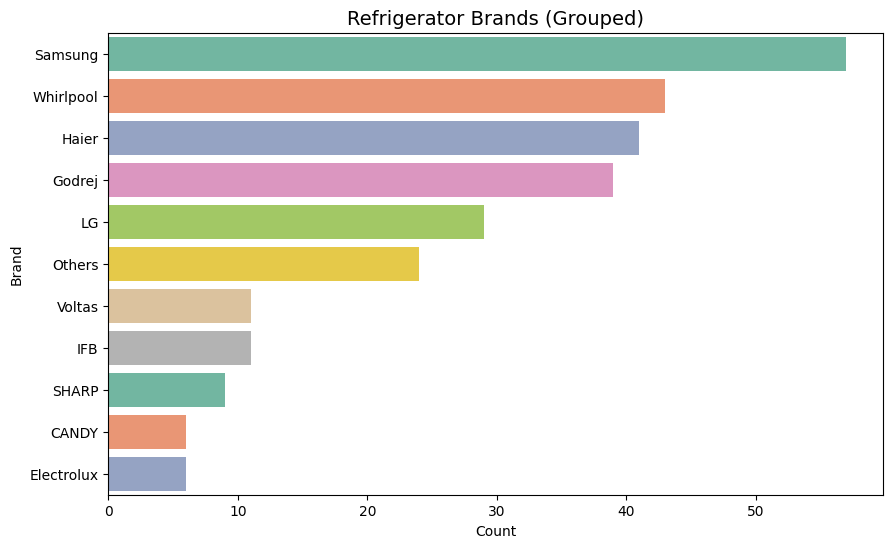

In [67]:
#Brand Distribution: 
brand_counts = df['Brand'].value_counts()
df['Brand_Grouped'] = df['Brand'].apply(lambda x: x if brand_counts[x] > 5 else 'Others')

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Brand_Grouped', order=df['Brand_Grouped'].value_counts().index, palette='Set2')
plt.title('Refrigerator Brands (Grouped)', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Brand')
plt.show()


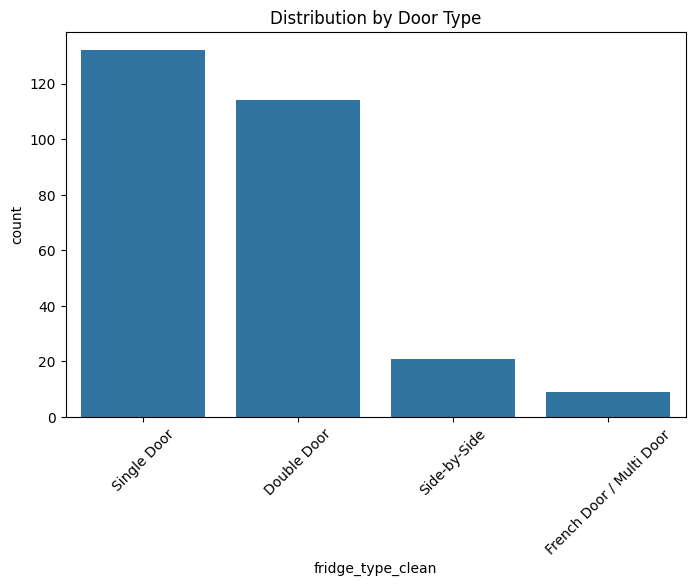

In [68]:
# 2. Door Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='fridge_type_clean', order=df['fridge_type_clean'].value_counts().index)
plt.title('Distribution by Door Type')
plt.xticks(rotation=45)
plt.show()

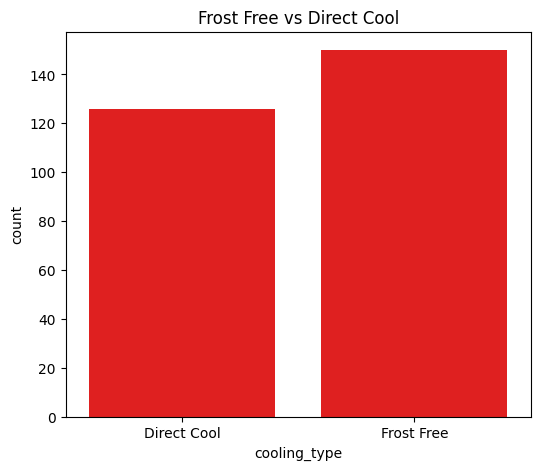

In [69]:
# 3. Cooling Type
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='cooling_type',color='red')
plt.title('Frost Free vs Direct Cool')
plt.show()


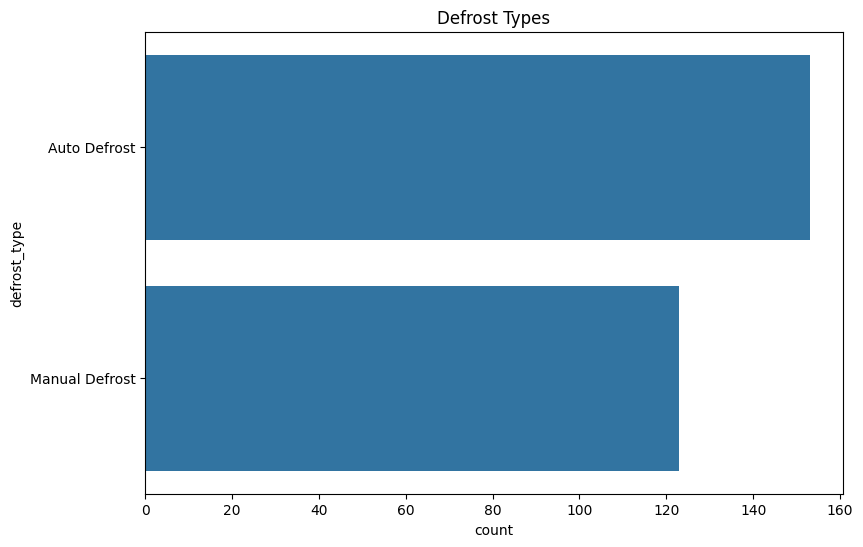

In [70]:
# 4. Defrost Type
plt.figure(figsize=(9, 6))
sns.countplot(data=df, y='defrost_type', order=df['defrost_type'].value_counts().index)
plt.title('Defrost Types')
plt.show()

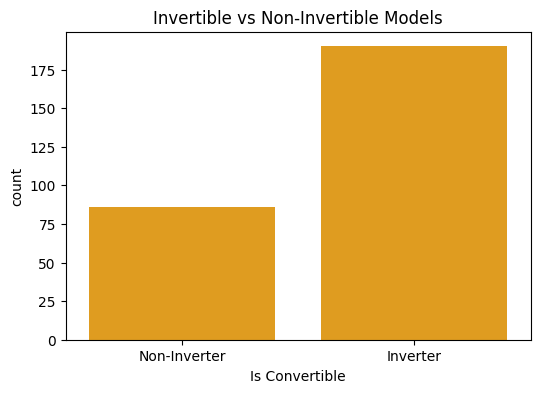

In [71]:
# 5. Invertible feature (True/False)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Compressor',color='orange')
plt.title('Invertible vs Non-Invertible Models')
plt.xlabel('Is Convertible')
plt.show()

### ➖ Numerical Data 

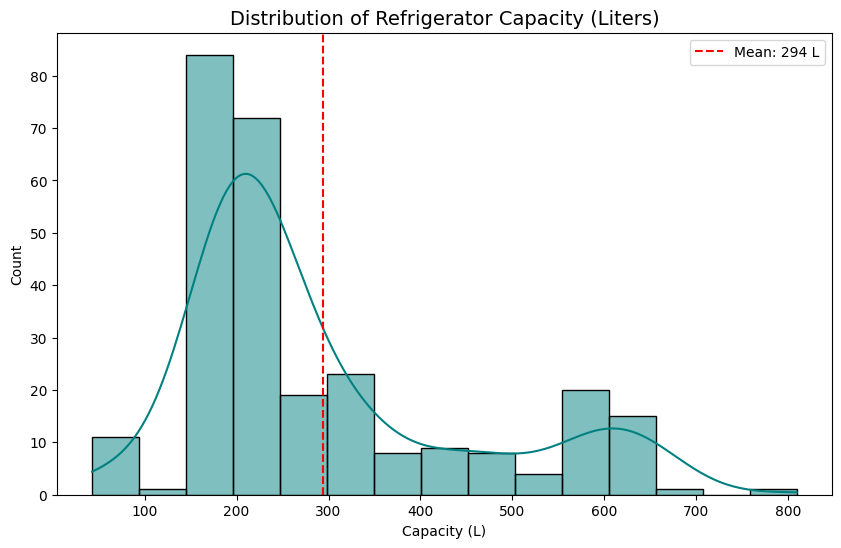

In [73]:
# 1. Capacity (in Liters)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Capacity', bins=15, kde=True, color='teal')
plt.title('Distribution of Refrigerator Capacity (Liters)', fontsize=14)
plt.xlabel('Capacity (L)')
plt.ylabel('Count')
plt.axvline(df['Capacity'].mean(), color='red', linestyle='--', label=f'Mean: {df["Capacity"].mean():.0f} L')
plt.legend()
plt.show()

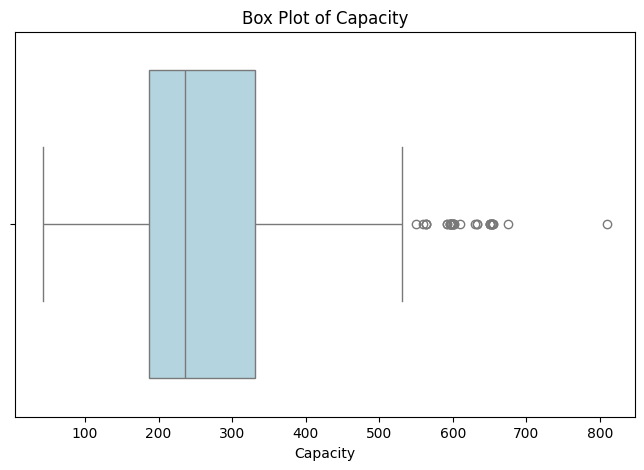

In [74]:
# Boxplot for capacity (good for seeing outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Capacity'], color='lightblue')
plt.title('Box Plot of Capacity')
plt.show()


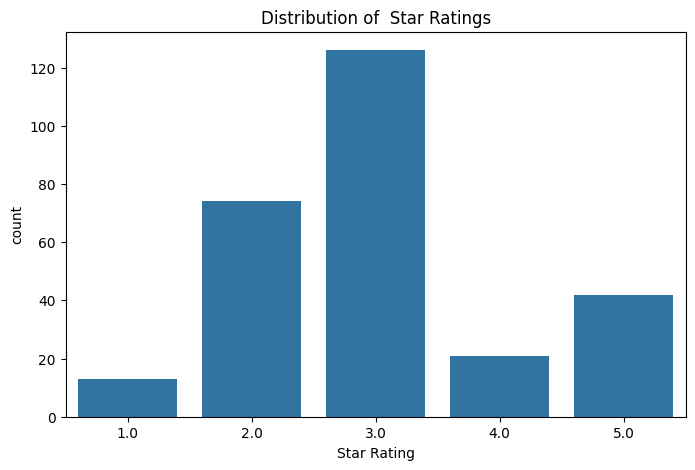

In [75]:
# 2. Star Rating (usually 2–5)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='star_rating')  
plt.title('Distribution of  Star Ratings')
plt.xlabel('Star Rating')
plt.show()

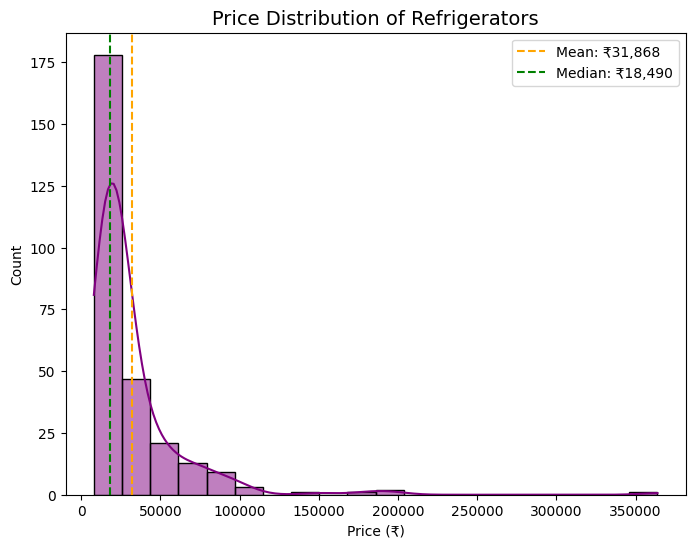

In [76]:
# 3. Product Price (most important — usually skewed)
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Price', bins=20, kde=True, color='purple')
plt.title('Price Distribution of Refrigerators', fontsize=14)
plt.xlabel('Price (₹)')
plt.ylabel('Count')
plt.axvline(df['Price'].mean(), color='orange', linestyle='--', label=f'Mean: ₹{df["Price"].mean():,.0f}')
plt.axvline(df['Price'].median(), color='green', linestyle='--', label=f'Median: ₹{df["Price"].median():,.0f}')
plt.legend()
plt.show()

## 💠Bivariant Analysis

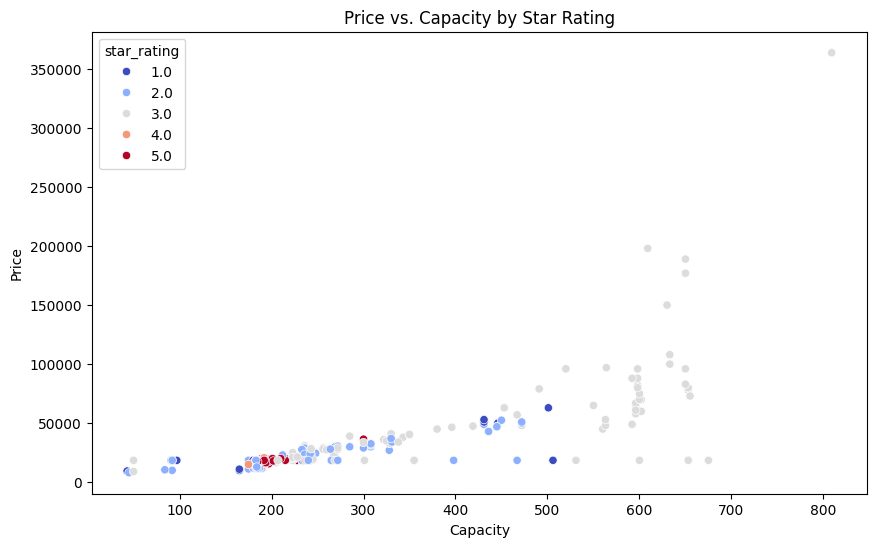

In [78]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Capacity', y='Price', hue='star_rating', palette='coolwarm')
plt.title('Price vs. Capacity by Star Rating')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_28328\3275522518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating_Category', palette='muted')


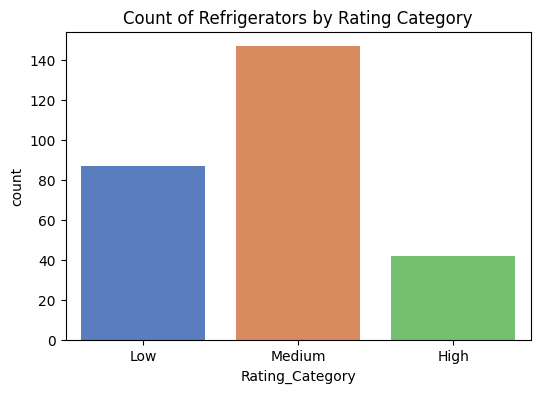

In [79]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Rating_Category', palette='muted')
plt.title('Count of Refrigerators by Rating Category')
plt.show()

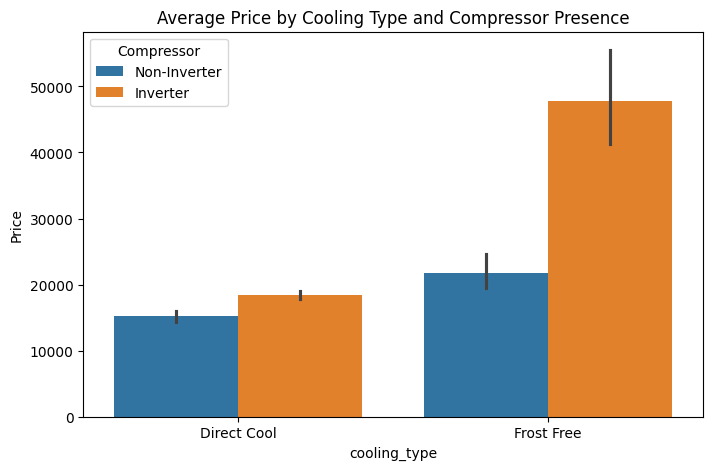

In [81]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='cooling_type', y='Price', hue='Compressor', estimator='mean')
plt.title('Average Price by Cooling Type and Compressor Presence')
plt.show()

In [82]:
top_brands = df['Brand'].value_counts().head(5).index
top_brands

Index(['Samsung', 'Whirlpool', 'Haier', 'Godrej', 'LG'], dtype='object', name='Brand')

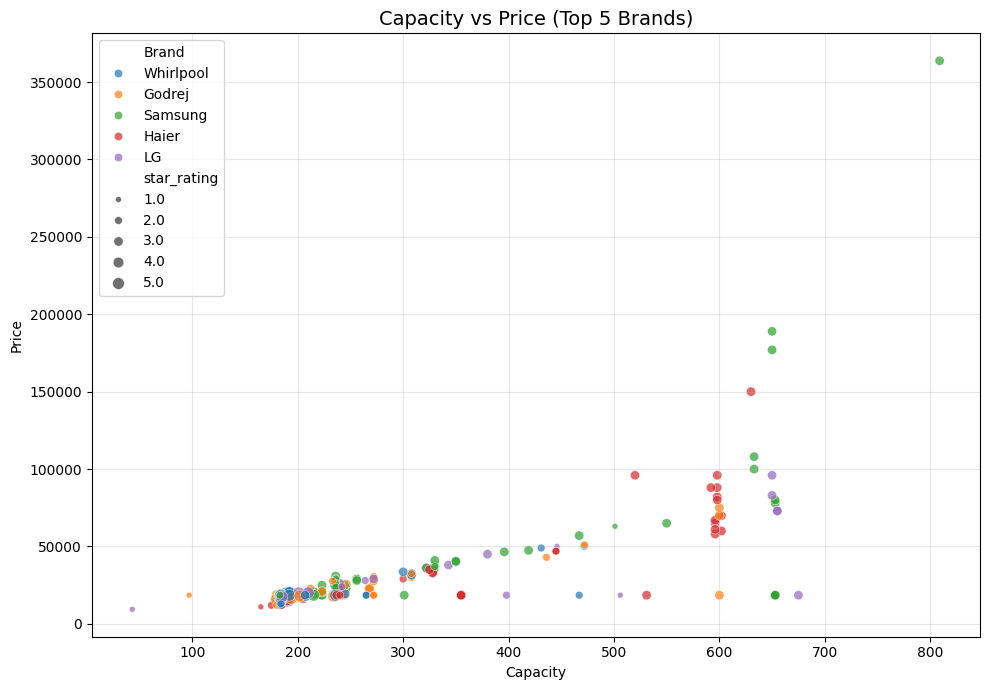

In [83]:
top_brands = df['Brand'].value_counts().head(5).index
df_top = df[df['Brand'].isin(top_brands)]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_top,
    x='Capacity',
    y='Price',
    hue='Brand',
    size='star_rating',
    alpha=0.7,
    palette='tab10'
)
plt.title('Capacity vs Price (Top 5 Brands)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_28328\346625980.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


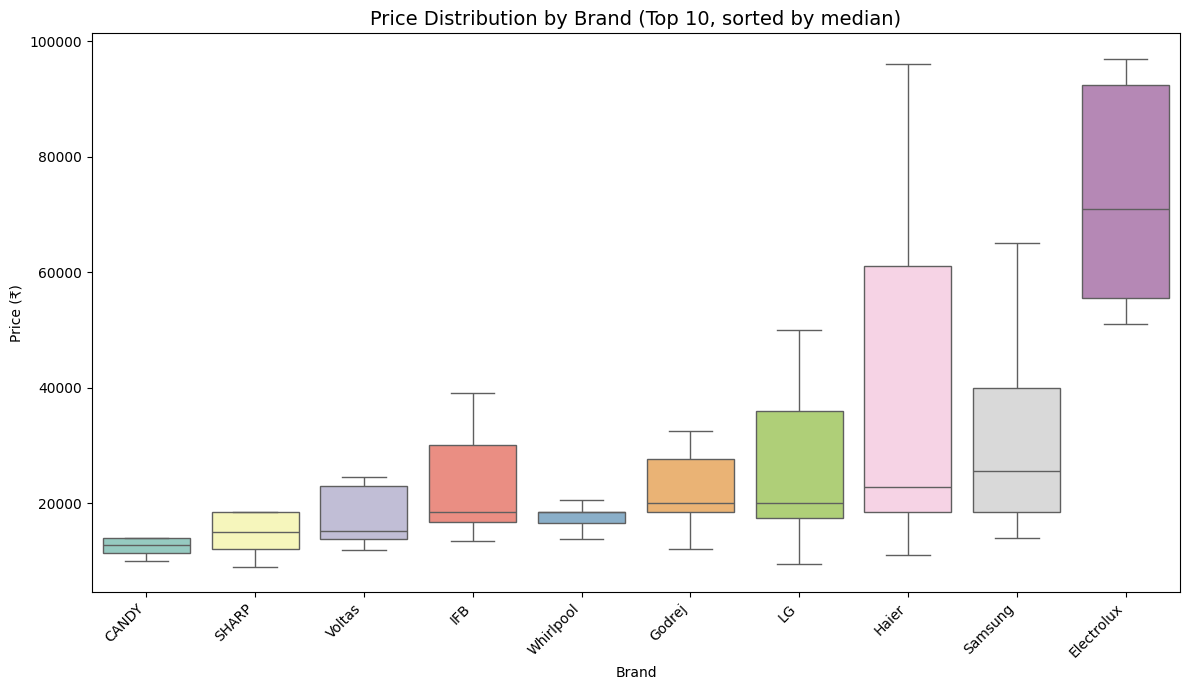

In [84]:
top_brands = df['Brand'].value_counts().head(10).index

df_top = df[df['Brand'].isin(top_brands)]

order = (
    df_top.groupby('Brand')['Price']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_top,
    x='Brand',
    y='Price',
    order=order,
    palette='Set3',
    showfliers=False   # hides extreme outliers
)

plt.title('Price Distribution by Brand (Top 10, sorted by median)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_28328\3088832262.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fridge_type_clean', y='Price', palette='viridis')


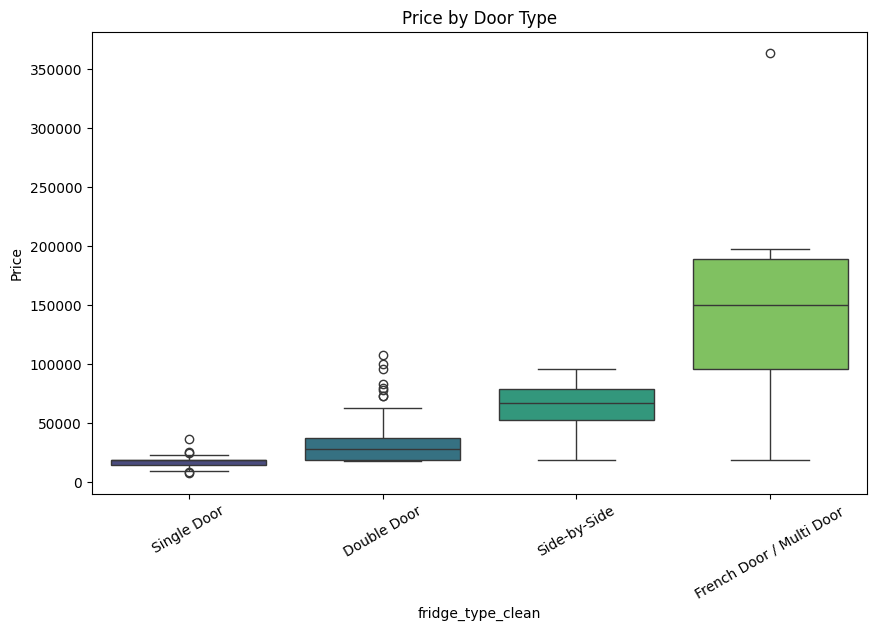

In [85]:
#Door Type vs Price
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='fridge_type_clean', y='Price', palette='viridis')
plt.title('Price by Door Type')
plt.xticks(rotation=30)
plt.show()

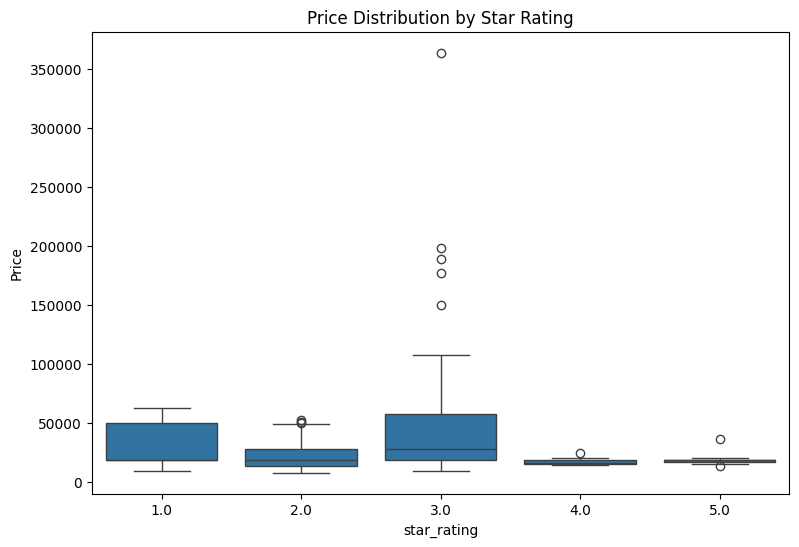

In [164]:
#Star_rating Vs Price
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='star_rating', y='Price')
plt.title('Price Distribution by Star Rating')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_28328\1046991819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Compressor', y='Price', palette='coolwarm')


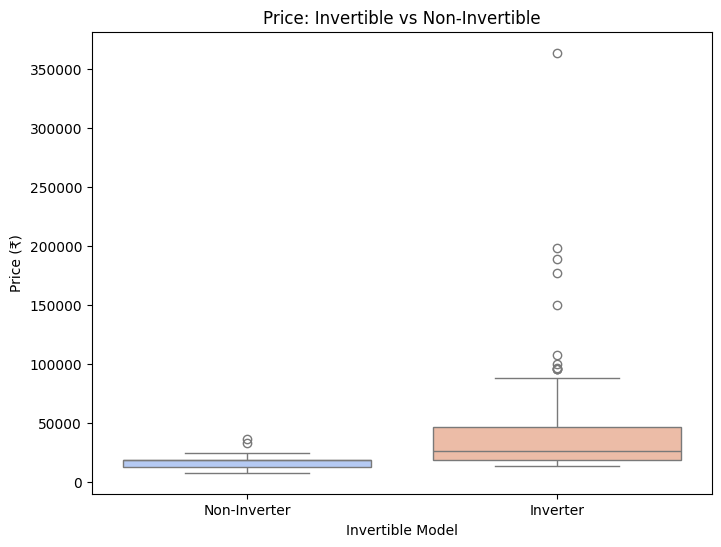

In [87]:
#Convertible vs Price
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Compressor', y='Price', palette='coolwarm')
plt.title('Price: Invertible vs Non-Invertible')
plt.xlabel('Invertible Model')
plt.ylabel('Price (₹)')
plt.show()

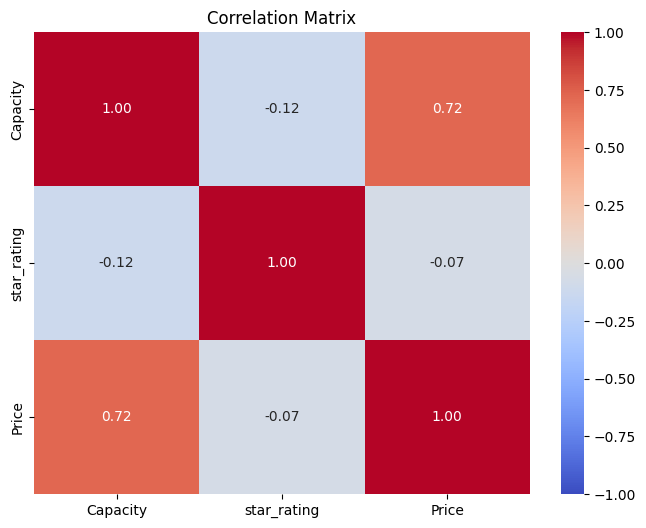

In [88]:
numeric_cols = ['Capacity', 'star_rating', 'Price']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()